# Evaluate BOOKING Isolation Forest (v1)

Evaluates an Isolation Forest (trained on BOOKING ALLOW) against labeled BOOKING data from one or more JSONL files.

What this answers:
- **ALLOW FP rate**: how often human-like samples are incorrectly flagged as anomaly.
- **BLOCK recall**: how often macro samples are flagged as anomaly.

Decision rule:
- model output `decision_function` is **higher = more normal**
- anomaly is flagged when `decision_function < meta.threshold.decision_function_threshold`


In [1]:
import json
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

args = SimpleNamespace(
    # Trained artifact folder
    ISOFOREST_DIR=Path("../model_joblib/isoforest_booking_v1/booking"),
    # One or more JSONL files (or directories containing *.jsonl)
    JSONL_INPUTS=[
        # r"C:\\path\\to\\eval.jsonl",
        # r"C:\\path\\to\\eval_jsonl_dir",
        r"C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\test_final\test.final.jsonl"
    ],
    TARGET_TYPE="BOOKING",
    ALLOW_LABEL="ALLOW",
    BLOCK_LABEL="BLOCK",
)
args

namespace(ISOFOREST_DIR=WindowsPath('../model_joblib/isoforest_booking_v1/booking'),
          JSONL_INPUTS=['C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\test_final\\test.final.jsonl'],
          TARGET_TYPE='BOOKING',
          ALLOW_LABEL='ALLOW',
          BLOCK_LABEL='BLOCK')

In [2]:
def _expand_jsonl_inputs(inputs: list[str]) -> list[Path]:
    paths: list[Path] = []
    for raw in inputs:
        p = Path(str(raw)).expanduser()
        if p.is_dir():
            paths.extend(sorted(p.rglob("*.jsonl")))
        else:
            paths.append(p)
    out = [p.resolve() for p in paths if p.exists() and p.suffix.lower() == ".jsonl"]
    if not out:
        raise FileNotFoundError("No JSONL files found. Set args.JSONL_INPUTS.")
    return out


def load_jsonl_rows(paths: list[Path]) -> list[dict]:
    rows: list[dict] = []
    for p in paths:
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
    return rows


def rows_to_frame(rows: list[dict], feature_names: list[str]) -> pd.DataFrame:
    records = []
    for r in rows:
        feats = r.get("features") or {}
        rec = {
            "trialID": r.get("trialID"),
            "record_id": r.get("record_id"),
            "event_id": r.get("event_id"),
            "type": r.get("type"),
            "label": r.get("label") or (r.get("summary") or {}).get("label"),
        }
        for fn in feature_names:
            rec[fn] = feats.get(fn)
        records.append(rec)
    df = pd.DataFrame.from_records(records)
    for fn in feature_names:
        df[fn] = pd.to_numeric(df[fn], errors="coerce")
    return df


jsonl_paths = _expand_jsonl_inputs(args.JSONL_INPUTS)
len(jsonl_paths), str(jsonl_paths[0])

(1,
 'C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\test_final\\test.final.jsonl')

In [3]:
# Load artifact
isoforest_dir = Path(args.ISOFOREST_DIR).expanduser().resolve()
model_path = isoforest_dir / "model.joblib"
meta_path = isoforest_dir / "meta.json"

pipe = joblib.load(model_path)
meta = json.loads(meta_path.read_text(encoding="utf-8"))
features = list(meta["feature_names"])
threshold = float(meta["threshold"]["decision_function_threshold"])

print("loaded:")
print(model_path)
print(meta_path)
print("n_features:", len(features))
print("threshold:", threshold)

loaded:
C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\isoforest_booking_v1\booking\model.joblib
C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\isoforest_booking_v1\booking\meta.json
n_features: 30
threshold: -0.15668254871614892


In [4]:
rows = load_jsonl_rows(jsonl_paths)
df = rows_to_frame(rows, features)

df["type_u"] = df["type"].astype(str).str.strip().str.upper()
df["label_u"] = df["label"].astype(str).str.strip().str.upper()

target_type = str(args.TARGET_TYPE).strip().upper()
allow_label = str(args.ALLOW_LABEL).strip().upper()
block_label = str(args.BLOCK_LABEL).strip().upper()

df_booking = df[df["type_u"] == target_type].copy()
df_booking = df_booking[df_booking["label_u"].isin([allow_label, block_label])].copy()

print("BOOKING labeled rows:", len(df_booking))
print(df_booking["label_u"].value_counts(dropna=False).to_string())

if len(df_booking) == 0:
    raise RuntimeError("No labeled BOOKING samples found in provided JSONL(s).")

BOOKING labeled rows: 839
label_u
ALLOW    638
BLOCK    201


In [5]:
# Evaluate
X = df_booking[features]
scores = np.asarray(pipe.decision_function(X), dtype=float)
is_anomaly = (scores < threshold).astype(int)  # 1 = anomaly

# Ground truth: treat BLOCK as anomaly=1, ALLOW as anomaly=0
y_true = (df_booking["label_u"].values == block_label).astype(int)
y_pred = is_anomaly

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])

precision = (tp / (tp + fp)) if (tp + fp) else 0.0
recall = (tp / (tp + fn)) if (tp + fn) else 0.0
fpr_allow = (fp / (fp + tn)) if (fp + tn) else 0.0

print("confusion_matrix [[TN, FP],[FN, TP]]:")
print(cm)
print("precision(BLOCK-as-anomaly):", precision)
print("recall(BLOCK-as-anomaly):", recall)
print("ALLOW false-positive rate:", fpr_allow)

print("\nclassification_report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["ALLOW(normal)", "BLOCK(anomaly)"],
        zero_division=0,
        digits=4,
    )
)

confusion_matrix [[TN, FP],[FN, TP]]:
[[638   0]
 [201   0]]
precision(BLOCK-as-anomaly): 0.0
recall(BLOCK-as-anomaly): 0.0
ALLOW false-positive rate: 0.0

classification_report:
                precision    recall  f1-score   support

 ALLOW(normal)     0.7604    1.0000    0.8639       638
BLOCK(anomaly)     0.0000    0.0000    0.0000       201

      accuracy                         0.7604       839
     macro avg     0.3802    0.5000    0.4320       839
  weighted avg     0.5783    0.7604    0.6569       839



In [6]:
# Threshold sweep: pick threshold by ALLOW FP target, then measure BLOCK recall
# decision_function: higher = more normal; anomaly when score < threshold

allow_mask = (df_booking["label_u"].values == allow_label)
block_mask = (df_booking["label_u"].values == block_label)
scores_allow = np.asarray(scores[allow_mask], dtype=float)

fp_targets = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

rows = []
for fp_t in fp_targets:
    fp_t = float(fp_t)
    fp_t = min(max(fp_t, 0.0), 0.5)
    thr = float(np.quantile(scores_allow, fp_t))
    pred = (scores < thr).astype(int)

    tn = int(np.sum((y_true == 0) & (pred == 0)))
    fp = int(np.sum((y_true == 0) & (pred == 1)))
    fn = int(np.sum((y_true == 1) & (pred == 0)))
    tp = int(np.sum((y_true == 1) & (pred == 1)))

    allow_fpr = (fp / (fp + tn)) if (fp + tn) else 0.0
    block_recall = (tp / (tp + fn)) if (tp + fn) else 0.0
    block_precision = (tp / (tp + fp)) if (tp + fp) else 0.0

    rows.append({
        "fp_target": fp_t,
        "threshold": thr,
        "ALLOW_FPR": float(allow_fpr),
        "BLOCK_recall": float(block_recall),
        "BLOCK_precision": float(block_precision),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

sweep_df = pd.DataFrame(rows)
sweep_df = sweep_df.sort_values(["ALLOW_FPR", "threshold"], ascending=[True, True])
sweep_df

,fp_target,threshold,ALLOW_FPR,BLOCK_recall,BLOCK_precision,TN,FP,FN,TP
0,0.0000,-0.110615,0.000000,0.000000,0.000000,638,0,201,0
1,0.0005,-0.109578,0.001567,0.000000,0.000000,637,1,201,0
2,0.0010,-0.108542,0.001567,0.000000,0.000000,637,1,201,0
3,0.0020,-0.105489,0.003135,0.000000,0.000000,636,2,201,0
4,0.0050,-0.086680,0.006270,0.094527,0.826087,634,4,182,19
5,0.0100,-0.059254,0.010972,0.422886,0.923913,631,7,116,85
6,0.0200,-0.049073,0.020376,0.502488,0.885965,625,13,100,101
7,0.0500,-0.019880,0.050157,0.865672,0.844660,606,32,27,174


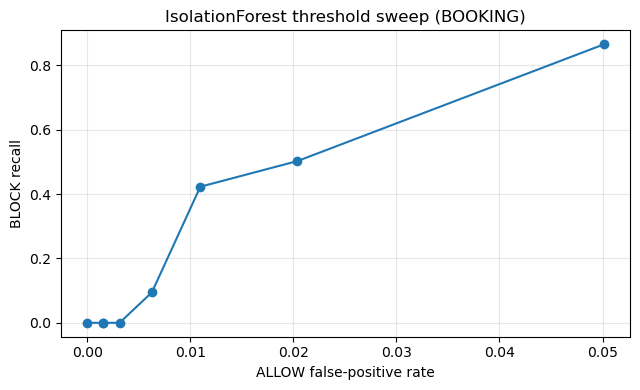

In [7]:
# Plot: BLOCK recall vs ALLOW FPR
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5, 4))
plt.plot(sweep_df["ALLOW_FPR"], sweep_df["BLOCK_recall"], marker="o")
plt.title("IsolationForest threshold sweep (BOOKING)")
plt.xlabel("ALLOW false-positive rate")
plt.ylabel("BLOCK recall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

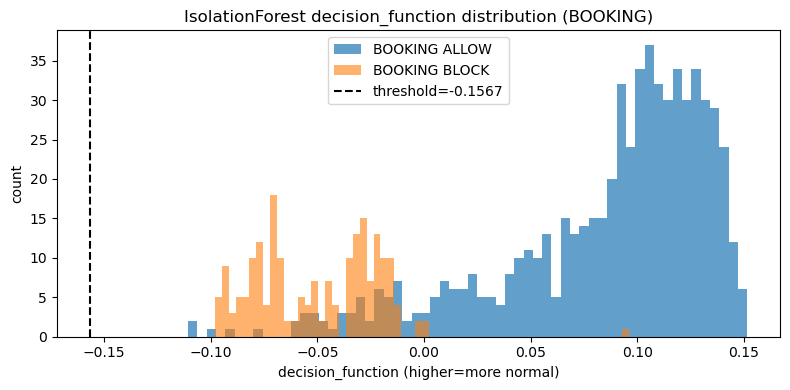

In [8]:
# Distributions
import matplotlib.pyplot as plt

scores_allow = scores[df_booking["label_u"].values == allow_label]
scores_block = scores[df_booking["label_u"].values == block_label]

plt.figure(figsize=(8, 4))
bins = 60
plt.hist(scores_allow, bins=bins, alpha=0.7, label=f"BOOKING {allow_label}")
plt.hist(scores_block, bins=bins, alpha=0.6, label=f"BOOKING {block_label}")
plt.axvline(threshold, color="black", linestyle="--", label=f"threshold={threshold:.4f}")
plt.title("IsolationForest decision_function distribution (BOOKING)")
plt.xlabel("decision_function (higher=more normal)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Optional: inspect top-k most anomalous predicted samples
df_out = df_booking[["trialID", "record_id", "event_id", "label_u"]].copy()
df_out["decision_function"] = scores
df_out["pred_anomaly"] = y_pred
df_out.sort_values("decision_function", ascending=True).head(30)

,trialID,record_id,event_id,label_u,decision_function,pred_anomaly
761,95,rec_ae983cefbc9543b2,6061,ALLOW,-0.110615,0
969,303,rec_b937f2a6f7b44b6e,6061,ALLOW,-0.107361,0
919,253,rec_d6d7973da09c4985,6061,ALLOW,-0.100530,0
270,65,rec_2dfbc1c2c5e94f23,6034,BLOCK,-0.098061,0
298,93,rec_4848fc72744f4573,6034,BLOCK,-0.097738,0
104,23,rec_f5e05f17e1c54e61,6034,BLOCK,-0.097037,0
15,16,rec_aad214f0190c4af1,6034,BLOCK,-0.095459,0
165,84,rec_a06593cb1a2e4cfa,6034,BLOCK,-0.094947,0
127,46,rec_bb9b3ba4e204465a,6034,BLOCK,-0.094762,0
6,7,rec_2c64866f2e324bd4,6034,BLOCK,-0.093807,0
